In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

sns.set_theme(style="whitegrid")

In [ ]:

df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')

display(df.head())

print("\n--- Data Information ---")
df.info()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9058-HRZSV,1,United States,California,Baldwin Park,91706,"34.098275, -117.967399",34.098275,-117.967399,Female,...,Month-to-month,No,Electronic check,94.40,6126.15,No,0,7,5348,NaN
2,4767-HZZHQ,1,United States,California,Redondo Beach,90277,"33.830453, -118.384565",33.830453,-118.384565,Male,...,Month-to-month,No,Bank transfer (automatic),82.05,2570.2,No,0,9,5036,NaN
3,8734-DKSTZ,1,United States,California,Winterhaven,92283,"32.852947, -114.850784",32.852947,-114.850784,Female,...,Month-to-month,No,Electronic check,85.95,858.6,No,0,20,4922,NaN
4,0913-XWSCN,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Month-to-month,No,Bank transfer (automatic),85.50,4713.4,No,0,20,6411,NaN



--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16

In [ ]:
city_counts = df["City"].value_counts(dropna=False)
distinct_city_count = df["City"].nunique(dropna=False)

print(f"Distinct cities: {distinct_city_count:,}")
display(city_counts.rename("customer_count").to_frame())

Shape of dataset after safe cleaning: (7032, 20)



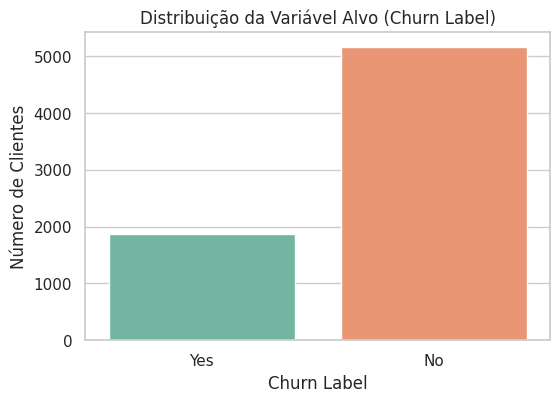

Porcentagem de Retenção (No): 73.42%
Porcentagem de Churn (Yes): 26.58%


In [3]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')

columns_to_drop = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Lat Long', 'Latitude', 'Longitude', 'Churn Value', 'Churn Score', 
    'CLTV', 'Churn Reason', 'TotalCharges']

cols_to_drop = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

df.dropna(subset=['Total Charges'], inplace=True)

print(f"Shape of dataset after safe cleaning: {df.shape}\n")

target_col = 'Churn Label' 

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=target_col, hue=target_col, palette='Set2', legend=False)
plt.title(f'Distribuição da Variável Alvo ({target_col})')
plt.ylabel('Número de Clientes')
plt.show()

churn_rate = df[target_col].value_counts(normalize=True) * 100
print(f"Porcentagem de Retenção (No): {churn_rate.get('No', 0):.2f}%")
print(f"Porcentagem de Churn (Yes): {churn_rate.get('Yes', 0):.2f}%")

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col])
y = df[target_col].map({'Yes': 1, 'No': 0})

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (5625, 30)
Testing data shape: (1407, 30)


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, accuracy_score
import mlflow

mlflow.set_experiment("Telco_Churn_Baselines")

with mlflow.start_run(run_name="Dummy_Classifier"):
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
    
    acc_dummy = accuracy_score(y_test, y_pred_dummy)
    f1_dummy = f1_score(y_test, y_pred_dummy) 
    
    mlflow.log_param("model_type", "DummyClassifier")
    mlflow.log_metric("accuracy", acc_dummy)
    mlflow.log_metric("f1_score", f1_dummy)
    
    print("--- Dummy Classifier ---")
    print(f"Accuracy: {acc_dummy:.4f} | F1-Score: {f1_dummy:.4f}")

with mlflow.start_run(run_name="Logistic_Regression_Scaled"):
    
    pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=42)
    )
    
    pipeline.fit(X_train, y_train)
    
    y_pred_log = pipeline.predict(X_test)
    
    acc_log = accuracy_score(y_test, y_pred_log)
    f1_log = f1_score(y_test, y_pred_log)
    
    mlflow.log_param("model_type", "LogisticRegression_Scaled")
    mlflow.log_metric("accuracy", acc_log)
    mlflow.log_metric("f1_score", f1_log)
    
    print("\n--- Logistic Regression (Scaled) ---")
    print(f"Accuracy: {acc_log:.4f} | F1-Score: {f1_log:.4f}")

--- Dummy Classifier ---
Accuracy: 0.7342 | F1-Score: 0.0000

--- Logistic Regression (Scaled) ---
Accuracy: 0.8031 | F1-Score: 0.6014
